<a href="https://colab.research.google.com/github/iddadobroc/DSML_Group11_Clustering/blob/main/DSML_Group11LA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOVA Information Management School
Data Science and Machine Learning Group Project 2025/2026

---
# Reach for Change
Part 1: Uncovering Donor Profiles Through Clustering


| Student Number   | Name                       | Email                   |
| :-------------   | :------------------------- |:------------------------|
| 20251702         | Davide Corbo               | 20251702@novaims.unl.pt |
| 20251865         | Luis Alcaide               | 20251865@novaims.unl.pt |
| 20221685         | Fiifi Nyarko-Mensah        | 20221685@novaims.unl.pt |
| 20251105         | Adewusi Kehinde Abiola     | 20251105@novaims.unl.pt |


## May 2026


In [193]:
import pandas as pd


In [194]:

df = pd.read_csv('https://raw.githubusercontent.com/iddadobroc/DSML_Group11_Clustering/refs/heads/main/donors_descriptive.csv')
df.head()

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13560 entries, 0 to 13559
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CONTROL_NUMBER               13560 non-null  int64  
 1   CARD_PROM_12                 13297 non-null  float64
 2   CHILDREN                     13289 non-null  float64
 3   DONOR_AGE                    9970 non-null   float64
 4   DONOR_GENDER                 13303 non-null  object 
 5   FILE_CARD_GIFT               13292 non-null  float64
 6   FREQUENCY_STATUS_97NK        13296 non-null  float64
 7   HOME_OWNER                   13292 non-null  object 
 8   INCOME_GROUP                 10273 non-null  float64
 9   LAST_GIFT_AMT                13296 non-null  float64
 10  LIFETIME_CARD_PROM           13289 non-null  float64
 11  LIFETIME_GIFT_AMOUNT         13288 non-null  float64
 12  LIFETIME_GIFT_COUNT          13304 non-null  float64
 13  LIFETIME_MAX_GIF

In [196]:
df.shape

(13560, 40)

In [197]:
df.isna().sum()

,0
CONTROL_NUMBER,0
CARD_PROM_12,263
CHILDREN,271
DONOR_AGE,3590
DONOR_GENDER,257
FILE_CARD_GIFT,268
FREQUENCY_STATUS_97NK,264
HOME_OWNER,268
INCOME_GROUP,3287
LAST_GIFT_AMT,264


In [198]:
df

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
13556,7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
13557,115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN
13558,88067,6.0,1.000000,NaN,M,2.0,2.0,U,NaN,15.0,...,10.00,10.00,2.0,0.500,2.0,0.286,0.0,1,S,NaN


In [199]:
df1=df.copy()

In [200]:
df2=df.copy()
df2.drop(columns=["WEALTH_RATING"], inplace = True)

In [201]:
df1

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
13556,7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
13557,115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN
13558,88067,6.0,1.000000,NaN,M,2.0,2.0,U,NaN,15.0,...,10.00,10.00,2.0,0.500,2.0,0.286,0.0,1,S,NaN


In [202]:
df2['CONTROL_NUMBER'].duplicated().sum()

np.int64(0)

In [203]:
df1.set_index("CONTROL_NUMBER", inplace = True)

In [204]:
df1

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,6.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,17.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,28.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,32.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,33.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,12.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN


## 2. Data Preprocessing

### 2.1 Fix Invalid Placeholder Values

Several columns use non-standard strings to represent missing data: `SES` and `URBANICITY` encode unknowns as `'?'`, and `HOME_OWNER` uses `'U'` for unknown ownership status. These are replaced with `NaN` so they can be handled consistently during imputation.

First, check the unique values and the count of invalid entries in `SES`.

In [205]:
df2 = df1.copy()
# check uniques SES before cleaning
print('SES - unique values:', df2['SES'].unique())
print('SES - total "?":', (df2['SES'] == '?').sum())
print('SES - missing (NaN):', df2['SES'].isna().sum())

SES - unique values: ['2' '3' '1' '4' nan '?']
SES - total "?": 292
SES - missing (NaN): 286


Replace `'?'` in `SES` with `NaN`.

In [206]:
import numpy as np
df2['SES'] = df2['SES'].replace('?', np.nan)
print('SES - unique values:', df2['SES'].unique())
print('SES - missing (NaN):', df2['SES'].isna().sum())

SES - unique values: ['2' '3' '1' '4' nan]
SES - missing (NaN): 578


Same pattern for `URBANICITY`: check unique values and count `'?'` entries.

In [207]:
print('URBANICITY - unique values:', df2['URBANICITY'].unique())
print('URBANICITY - total "?":', (df2['URBANICITY'] == '?').sum())
print('URBANICITY - missing (NaN):', df2['URBANICITY'].isna().sum())

URBANICITY - unique values: ['T' 'R' 'U' 'C' 'S' nan '?']
URBANICITY - total "?": 295
URBANICITY - missing (NaN): 278


Replace `'?'` in `URBANICITY` with `NaN`.

In [208]:
df2['URBANICITY'] = df2['URBANICITY'].replace('?', np.nan)

print('URBANICITY - unique values:', df2['URBANICITY'].unique())
print('URBANICITY - missing (NaN):', df2['URBANICITY'].isna().sum())

URBANICITY - unique values: ['T' 'R' 'U' 'C' 'S' nan]
URBANICITY - missing (NaN): 573


`HOME_OWNER` uses `'U'` for unknown ownership status — replace with `NaN`.

In [209]:
print('HOME_OWNER unique before:', df2['HOME_OWNER'].unique())
df2['HOME_OWNER'] = df2['HOME_OWNER'].replace('U', np.nan)
print('HOME_OWNER unique after:', df2['HOME_OWNER'].unique())

HOME_OWNER unique before: ['H' 'U' nan]
HOME_OWNER unique after: ['H' nan]


### 2.2 Correct Out-of-Range Numeric Values

`PEP_STAR` and `RECENT_STAR_STATUS` are binary flags that should only take values in [0, 1], and `INCOME_GROUP` is an ordinal score in [1, 7]. The dataset contains float values outside these valid ranges, likely from data entry or encoding errors. Each column is clipped to its valid range and rounded to an integer.

First, inspect the unique values in `PEP_STAR`.

In [210]:
df2['PEP_STAR'].unique()

array([ 0.        ,  1.        , -0.5298607 ,         nan,  2.00360856])

In [211]:
print('\nPEP_STAR unique before:', sorted(df2['PEP_STAR'].dropna().unique()))
df2['PEP_STAR'] = df2['PEP_STAR'].clip(0, 1).round(0)
print('PEP_STAR unique after:', sorted(df2['PEP_STAR'].dropna().unique()))



PEP_STAR unique before: [np.float64(-0.5298607009385796), np.float64(0.0), np.float64(1.0), np.float64(2.0036085611535746)]
PEP_STAR unique after: [np.float64(0.0), np.float64(1.0)]


`RECENT_STAR_STATUS` — same approach as `PEP_STAR`: clip to [0, 1] and round.

In [212]:
print('\nRECENT_STAR_STATUS range before: [{:.2f}, {:.2f}]'.format(
    df2['RECENT_STAR_STATUS'].min(), df2['RECENT_STAR_STATUS'].max()))
df2['RECENT_STAR_STATUS'] = df2['RECENT_STAR_STATUS'].clip(0, 1).round()
print('RECENT_STAR_STATUS unique after:', sorted(df2['RECENT_STAR_STATUS'].dropna().unique()))



RECENT_STAR_STATUS range before: [-7.81, 22.00]
RECENT_STAR_STATUS unique after: [np.float64(0.0), np.float64(1.0)]


Verify `RECENT_STAR_STATUS` values after clamping.

In [213]:
df2['RECENT_STAR_STATUS'].unique()

array([ 0.,  1., nan])

`INCOME_GROUP` is an ordinal score [1–7]. Inspect the unique values before clamping.

In [214]:
df2['INCOME_GROUP'].unique()

array([ 5.        ,         nan,  4.        ,  6.        ,  3.        ,
        2.        ,  9.49079901,  1.        ,  7.        , -1.72899876])

In [215]:
print('\nINCOME_GROUP range before: [{:.2f}, {:.2f}]'.format(
    df2['INCOME_GROUP'].min(), df2['INCOME_GROUP'].max()))
df2['INCOME_GROUP'] = df2['INCOME_GROUP'].clip(1, 7).round()
print('INCOME_GROUP unique after:', sorted(df2['INCOME_GROUP'].dropna().unique()))



INCOME_GROUP range before: [-1.73, 9.49]
INCOME_GROUP unique after: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]


### 2.3 Fix Negative Values

Several financial and count variables — such as gift amounts, promotion counts, and income estimates — cannot meaningfully be negative. Scan all numeric columns for negative entries, then clip the identified columns to 0.

In [216]:
num_cols_all = df2.select_dtypes(include='number').columns
cols_with_negatives = np.array([c for c in num_cols_all if (df2[c] < 0).sum() > 0])


In [217]:
print('Colunas com valores negativos:')
print(cols_with_negatives)
print()
for c in cols_with_negatives:
    print(f'  {c}: {(df2[c] < 0).sum()} negatives  (min={df2[c].min():.3f})')

Colunas com valores negativos:
['CHILDREN' 'FILE_CARD_GIFT' 'FREQUENCY_STATUS_97NK' 'LAST_GIFT_AMT'
 'LIFETIME_CARD_PROM' 'LIFETIME_GIFT_AMOUNT' 'LIFETIME_GIFT_COUNT'
 'LIFETIME_MAX_GIFT_AMT' 'LIFETIME_MIN_GIFT_AMT' 'LIFETIME_PROM'
 'MEDIAN_HOME_VALUE' 'MEDIAN_HOUSEHOLD_INCOME' 'MONTHS_SINCE_FIRST_GIFT'
 'MONTHS_SINCE_LAST_PROM_RESP' 'NUMBER_PROM_12' 'PCT_ATTRIBUTE1'
 'PCT_ATTRIBUTE2' 'PCT_ATTRIBUTE3' 'PCT_ATTRIBUTE4' 'PER_CAPITA_INCOME'
 'RECENT_AVG_CARD_GIFT_AMT' 'RECENT_AVG_GIFT_AMT'
 'RECENT_CARD_RESPONSE_COUNT' 'RECENT_CARD_RESPONSE_PROP'
 'RECENT_RESPONSE_COUNT' 'RECENT_RESPONSE_PROP' 'WEALTH_RATING']

  CHILDREN: 75 negatives  (min=-2.341)
  FILE_CARD_GIFT: 64 negatives  (min=-10.100)
  FREQUENCY_STATUS_97NK: 70 negatives  (min=-1.365)
  LAST_GIFT_AMT: 70 negatives  (min=-21.719)
  LIFETIME_CARD_PROM: 68 negatives  (min=-7.189)
  LIFETIME_GIFT_AMOUNT: 66 negatives  (min=-245.473)
  LIFETIME_GIFT_COUNT: 70 negatives  (min=-18.583)
  LIFETIME_MAX_GIFT_AMT: 67 negatives  (min=-33.4

Clip all identified columns to a minimum of 0.

In [218]:
non_negative_cols = [
    'CHILDREN', 'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK',
    'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT',
    'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT',
    'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME',
    'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP',
    'NUMBER_PROM_12', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3',
    'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED', 'PER_CAPITA_INCOME',
    'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT',
    'RECENT_CARD_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_PROP',
    'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP', 'MONTHS_SINCE_LAST_GIFT',
    'CARD_PROM_12'
]

for col in non_negative_cols:
    if col in df2.columns:
        df2[col] = df2[col].clip(lower=0)

# Verify no negatives remain
remaining = {c: (df2[c] < 0).sum() for c in df2.select_dtypes(include='number').columns if (df2[c] < 0).sum() > 0}
print('Negatives :', remaining if remaining else "")

Negatives : {'WEALTH_RATING': np.int64(67)}


### 2.4 Handle Missing Values

After correcting invalid placeholders and out-of-range entries, check how many true missing values remain in each column. The imputation strategy varies by variable type.

In [219]:
missing = df2.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing.to_string())


Columns with missing values:
HOME_OWNER                     6309
WEALTH_RATING                  6269
DONOR_AGE                      3590
INCOME_GROUP                   3287
SES                             578
URBANICITY                      573
MONTHS_SINCE_LAST_PROM_RESP     430
PCT_ATTRIBUTE3                  282
MONTHS_SINCE_FIRST_GIFT         278
RECENT_CARD_RESPONSE_COUNT      278
PCT_ATTRIBUTE1                  276
LIFETIME_MAX_GIFT_AMT           276
RECENT_STAR_STATUS              275
MONTHS_SINCE_LAST_GIFT          275
LIFETIME_PROM                   274
RECENT_CARD_RESPONSE_PROP       274
NUMBER_PROM_12                  272
LIFETIME_GIFT_AMOUNT            272
LIFETIME_CARD_PROM              271
CHILDREN                        271
RECENT_AVG_GIFT_AMT             268
FILE_CARD_GIFT                  268
PCT_ATTRIBUTE4                  267
RECENT_RESPONSE_COUNT           266
RECENCY_STATUS_96NK             266
PEP_STAR                        265
FREQUENCY_STATUS_97NK           264

#### 2.4.1 Categorical Columns — Mode Imputation

`DONOR_GENDER`, `HOME_OWNER`, `RECENCY_STATUS_96NK`, `SES`, and `URBANICITY` all have a small proportion of missing values. Since these are categorical (nominal or ordinal), imputing with the most frequent value (mode) is the safest choice and avoids introducing arbitrary ordinal assumptions.

In [220]:
cat_cols = ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']
for col in cat_cols:
    n_miss = df2[col].isna().sum()
    mode_val = df2[col].mode()[0]
    print(f'{col}: {n_miss} missing | mode = {mode_val!r}')
    print(f'  {dict(df2[col].value_counts(dropna=False))}')
    print()

DONOR_GENDER: 257 missing | mode = 'F'
  {'F': np.int64(7222), 'M': np.int64(5376), 'U': np.int64(705), nan: np.int64(257)}

HOME_OWNER: 6309 missing | mode = 'H'
  {'H': np.int64(7251), nan: np.int64(6309)}

RECENCY_STATUS_96NK: 266 missing | mode = 'A'
  {'A': np.int64(8202), 'S': np.int64(2877), 'F': np.int64(1048), 'N': np.int64(825), 'E': np.int64(283), nan: np.int64(266), 'L': np.int64(59)}

SES: 578 missing | mode = '2'
  {'2': np.int64(6365), '1': np.int64(4091), '3': np.int64(2277), nan: np.int64(578), '4': np.int64(249)}

URBANICITY: 573 missing | mode = 'S'
  {'S': np.int64(3103), 'C': np.int64(2741), 'T': np.int64(2734), 'R': np.int64(2732), 'U': np.int64(1677), nan: np.int64(573)}



In [221]:
cat_cols = ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']
for col in cat_cols:
    mode_val = df2[col].mode()[0]
    df2[col] = df2[col].fillna(mode_val)

print('Missing in categorical columns')
print(df2[cat_cols].isna().sum())

Missing in categorical columns
DONOR_GENDER           0
HOME_OWNER             0
RECENCY_STATUS_96NK    0
SES                    0
URBANICITY             0
dtype: int64


#### 2.4.2 `CHILDREN` — Median Imputation

`CHILDREN` is an integer count of dependants. The median is preferred over the mean because the distribution is right-skewed. After filling, values are rounded and clamped to [0, 6] to ensure valid non-negative integers.

In [222]:
col = 'CHILDREN'
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')
print(f'Median: {df2[col].median()}')
print(f'\nValue counts:')
print(df2[col].value_counts(dropna=False).sort_index())

CHILDREN: 271 missing (2.0%)
Median: 2.0

Value counts:
CHILDREN
0.000000    2656
1.000000    2658
2.000000    2631
3.000000    2630
4.000000    2646
6.264709      68
NaN          271
Name: count, dtype: int64


In [223]:
df2['CHILDREN'] = df2['CHILDREN'].fillna(df2['CHILDREN'].median()).round().clip(0, 6)
print('CHILDREN after imputation:')
print(df2['CHILDREN'].value_counts(dropna=False).sort_index())
print(f'Missing: {df2["CHILDREN"].isna().sum()}')

CHILDREN after imputation:
CHILDREN
0.0    2656
1.0    2658
2.0    2902
3.0    2630
4.0    2646
6.0      68
Name: count, dtype: int64
Missing: 0


#### 2.4.3 `DONOR_AGE` — Median Imputation

In [224]:
col = 'DONOR_AGE'
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')
print(f'Median: {df2[col].median()} | Mean: {df2[col].mean():.1f}')
print(f'Min: {df2[col].min()} | Max: {df2[col].max()}')

DONOR_AGE: 3590 missing (26.5%)
Median: 60.0 | Mean: 58.9
Min: 0.0 | Max: 108.93426092026507


`DONOR_AGE` has 26.5% missing values. Age distributions are typically right-skewed, so the median is a more robust imputation choice than the mean.

In [225]:
df2['DONOR_AGE'] = df2['DONOR_AGE'].fillna(df2['DONOR_AGE'].median())
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')

DONOR_AGE: 0 missing (0.0%)


#### 2.4.4 `INCOME_GROUP` — Median Imputation

In [226]:
col = 'INCOME_GROUP'
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')
print(f'Median: {df2[col].median()}')
print(f'\nValue counts (incl. NaN):')
print(df2[col].value_counts(dropna=False).sort_index())

INCOME_GROUP: 3287 missing (24.2%)
Median: 4.0

Value counts (incl. NaN):
INCOME_GROUP
1.0    1278
2.0    1758
3.0    1133
4.0    1732
5.0    2177
6.0    1076
7.0    1119
NaN    3287
Name: count, dtype: int64


`INCOME_GROUP` is an ordinal score [1–7] with 24.2% missing values. Impute with the median, then round and clamp to [1, 7] to keep valid integer categories.

In [227]:
df2['INCOME_GROUP'] = df2['INCOME_GROUP'].fillna(df2['INCOME_GROUP'].median()).round().clip(1, 7)
print(df2[col].value_counts(dropna=False).sort_index())


INCOME_GROUP
1.0    1278
2.0    1758
3.0    1133
4.0    5019
5.0    2177
6.0    1076
7.0    1119
Name: count, dtype: int64


### 2.5 Duplicate Check & Correlation-Based Feature Selection

Before analysing feature relationships, remove any duplicate rows or repeated index values to ensure each donor appears exactly once. Then compute the Pearson correlation matrix to identify pairs of features that carry redundant information.

In [228]:
print('Duplicated index (CONTROL_NUMBER):', df2.index.duplicated().sum())
print('Duplicated rows (all columns):', df2.duplicated().sum())

Duplicated index (CONTROL_NUMBER): 0
Duplicated rows (all columns): 0


In [229]:
df2 = df2[~df2.index.duplicated(keep='first')]
df2 = df2.drop_duplicates()
print('Shape after duplicate removal:', df2.shape)

Shape after duplicate removal: (13560, 39)


#### 2.5.1 Pearson Correlation Matrix

Visualise pairwise linear correlations across all numeric features. Pairs with |r| > 0.75 are considered highly redundant — one variable from each pair will be dropped in the next step.

Dataset usado para Pearson: df2
Nº de variáveis no diagrama: 34


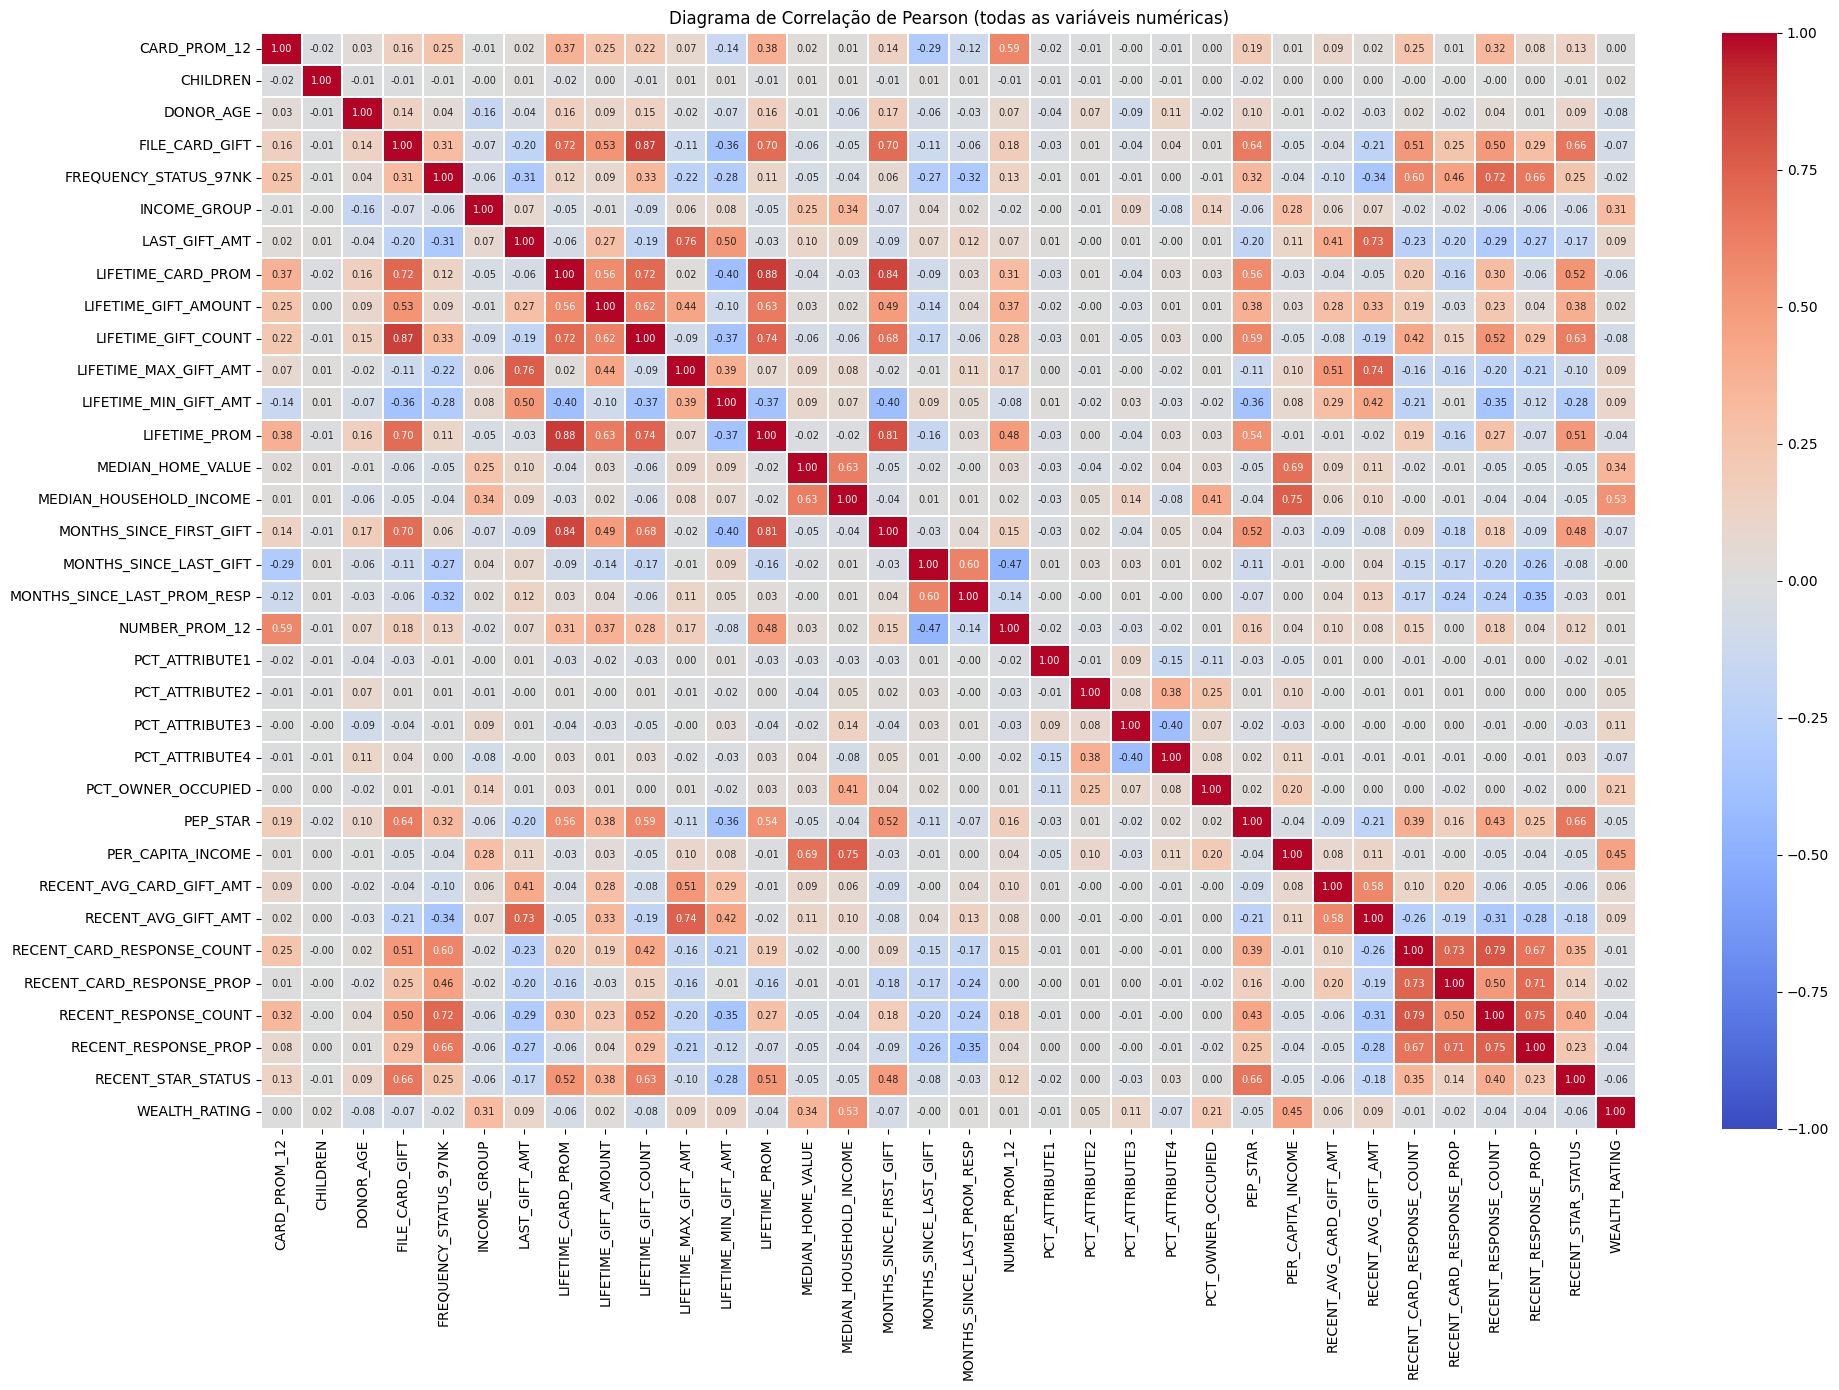

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt

# usar o dataset mais avançado que existir
if 'df5' in globals():
    df_corr_base = df5.copy()
elif 'df4' in globals():
    df_corr_base = df4.copy()
else:
    df_corr_base = df2.copy()

# Pearson só funciona em colunas numéricas
corr_df = df_corr_base.select_dtypes(include='number')
pearson_corr = corr_df.corr(method='pearson')

print('Dataset usado para Pearson:', 'df5' if 'df5' in globals() else ('df4' if 'df4' in globals() else 'df2'))
print('Nº de variáveis no diagrama:', pearson_corr.shape[0])

plt.figure(figsize=(20, 14))
sns.heatmap(
    pearson_corr,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=False,
    linewidths=0.2,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
    )
plt.title('Diagrama de Correlação de Pearson (todas as variáveis numéricas)')
plt.tight_layout()
plt.show()

In [231]:
import numpy as np
import pandas as pd

thr = 0.75

if 'pearson_corr' not in globals():
    corr_df = df5.select_dtypes(include='number') if 'df5' in globals() else df2.select_dtypes(include='number')
    pearson_corr = corr_df.corr(method='pearson')

corr_abs = pearson_corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_r'})
)
pairs = pairs[pairs['abs_r'] > thr].sort_values('abs_r', ascending=False).reset_index(drop=True)

# adicionar r com sinal para análise
pairs['r'] = pairs.apply(lambda x: pearson_corr.loc[x['var1'], x['var2']], axis=1)
pairs = pairs[['var1', 'var2', 'r', 'abs_r']]

print(f'Pares com |r| > {thr}: {len(pairs)}')
display(pairs)

# sugestao automatica simples: remover var2 de cada par
if len(pairs) > 0:
    suggested_remove = pairs['var2'].drop_duplicates().tolist()
    print('\nSugestao (automatica): remover uma por par, começando por estas:')
    print(suggested_remove)

Pares com |r| > 0.75: 7


,var1,var2,r,abs_r
0,LIFETIME_CARD_PROM,LIFETIME_PROM,0.880728,0.880728
1,FILE_CARD_GIFT,LIFETIME_GIFT_COUNT,0.866220,0.866220
2,LIFETIME_CARD_PROM,MONTHS_SINCE_FIRST_GIFT,0.843808,0.843808
3,LIFETIME_PROM,MONTHS_SINCE_FIRST_GIFT,0.806433,0.806433
4,RECENT_CARD_RESPONSE_COUNT,RECENT_RESPONSE_COUNT,0.788052,0.788052
5,LAST_GIFT_AMT,LIFETIME_MAX_GIFT_AMT,0.758006,0.758006
6,MEDIAN_HOUSEHOLD_INCOME,PER_CAPITA_INCOME,0.753560,0.753560



Sugestao (automatica): remover uma por par, começando por estas:
['LIFETIME_PROM', 'LIFETIME_GIFT_COUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_RESPONSE_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'PER_CAPITA_INCOME']


#### 2.5.2 Drop Correlated Features

Drop correlated features (|r| > 0.75) — keep the more informative variable in each pair.

- `LIFETIME_PROM` (r=0.88 with `LIFETIME_CARD_PROM`) → drop `LIFETIME_PROM`, keep `LIFETIME_CARD_PROM`
- `LIFETIME_GIFT_COUNT` (r=0.87 with `FILE_CARD_GIFT`) → drop `LIFETIME_GIFT_COUNT`, keep `FILE_CARD_GIFT`
- `MONTHS_SINCE_FIRST_GIFT` (r=0.84 with `LIFETIME_CARD_PROM`) → drop `MONTHS_SINCE_FIRST_GIFT`
- `RECENT_CARD_RESPONSE_COUNT` (r=0.79 with `RECENT_RESPONSE_COUNT`) → drop card count, keep total count
- `LIFETIME_MAX_GIFT_AMT` (r=0.76 with `LAST_GIFT_AMT`) → drop lifetime max, keep recency signal
- `MEDIAN_HOUSEHOLD_INCOME` (r=0.75 with `PER_CAPITA_INCOME`) → drop median household, keep per capita

Also drop `WEALTH_RATING` — pre-computed external score, not meaningful for unsupervised profiling.

Dropped: ['LIFETIME_PROM', 'LIFETIME_GIFT_COUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_CARD_RESPONSE_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'MEDIAN_HOUSEHOLD_INCOME', 'WEALTH_RATING']
Shape before: (13560, 39)
Shape after:  (13560, 32)


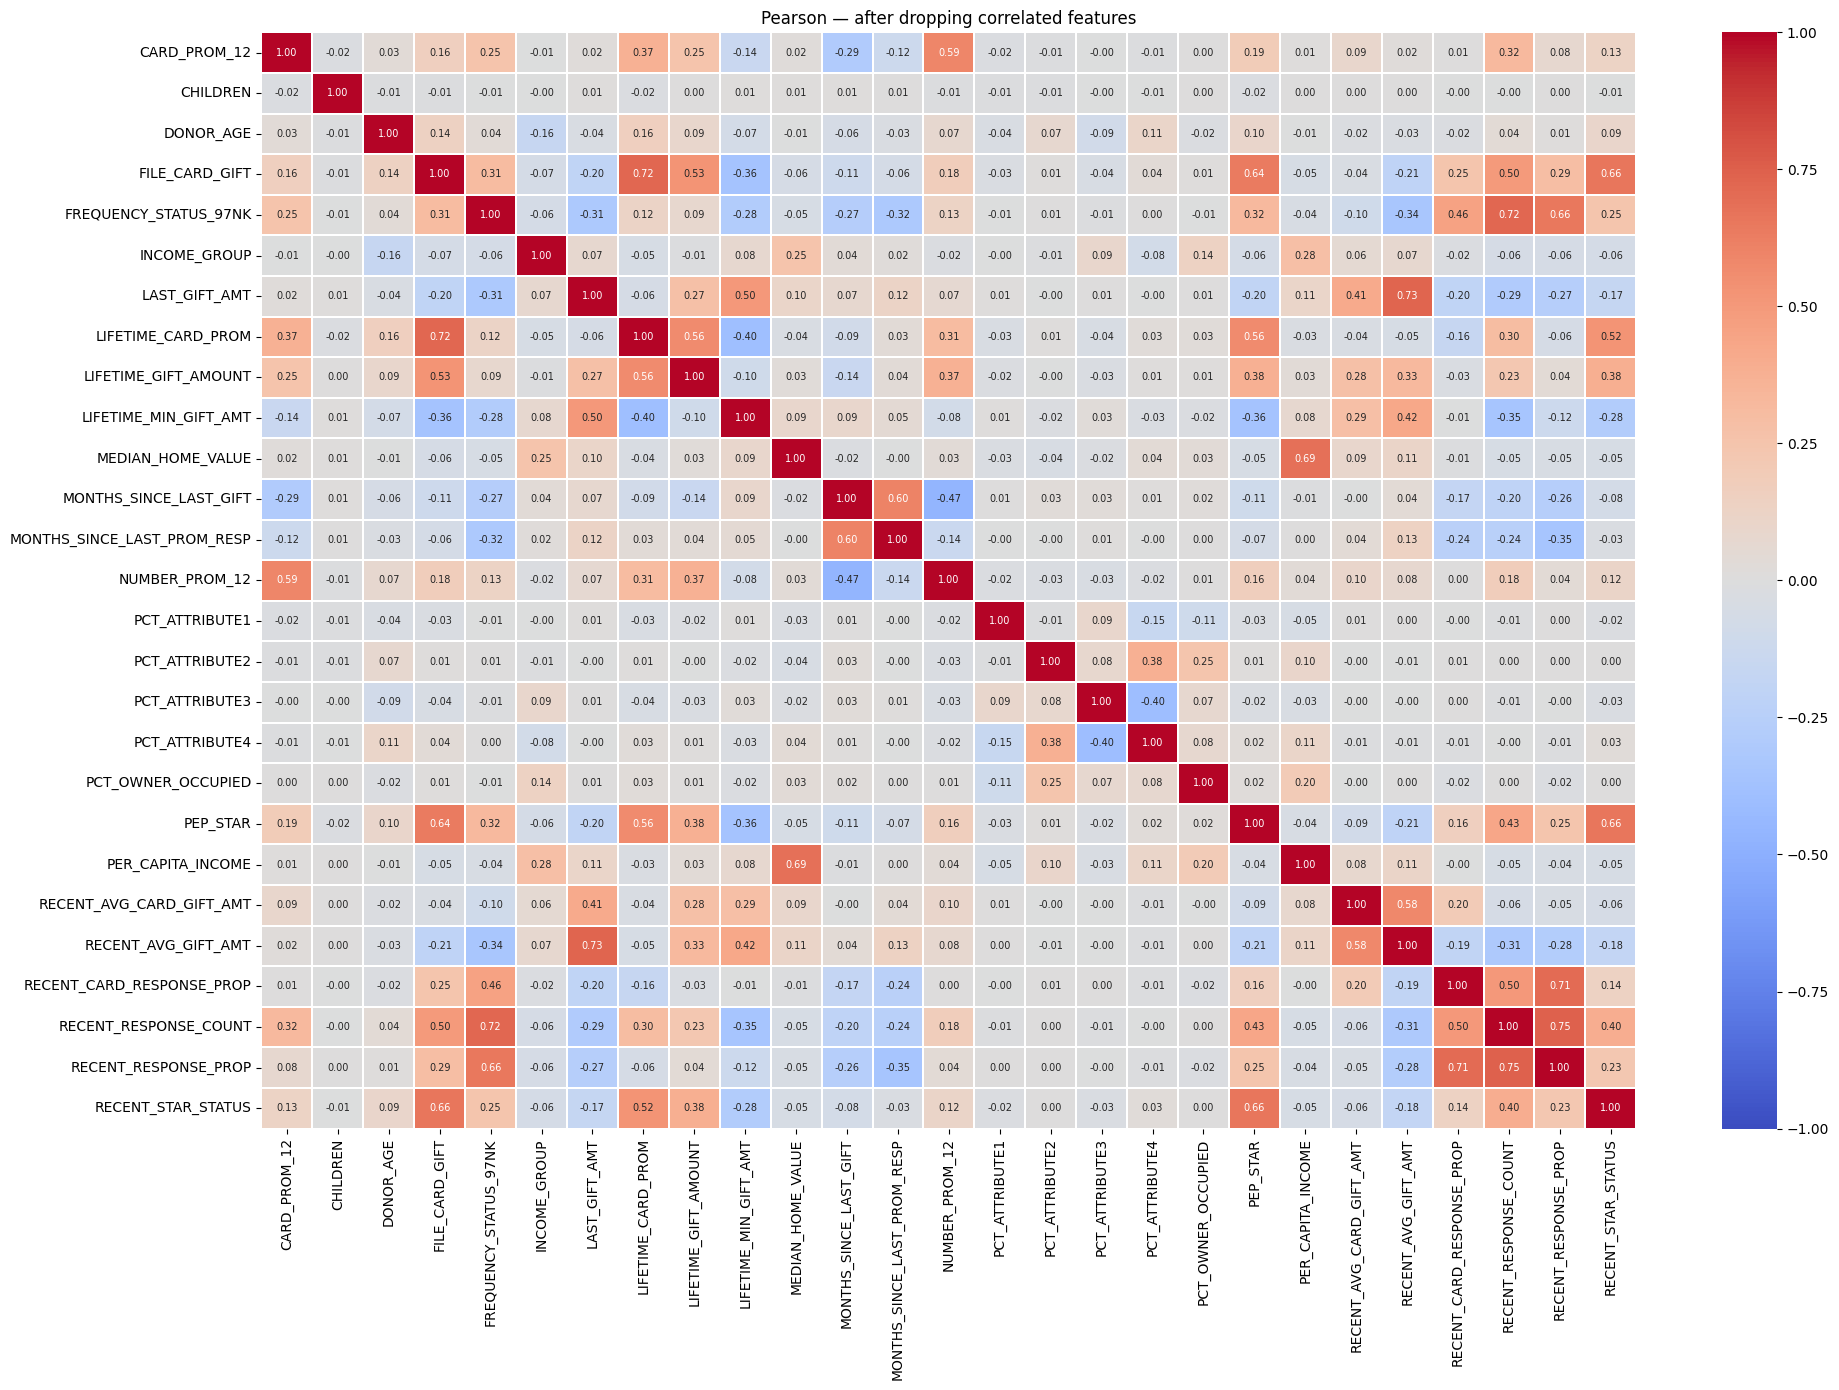

In [232]:
drop_cols = [
    'LIFETIME_PROM',            # r=0.88 with LIFETIME_CARD_PROM
    'LIFETIME_GIFT_COUNT',      # r=0.87 with FILE_CARD_GIFT
    'MONTHS_SINCE_FIRST_GIFT',  # r=0.84 with LIFETIME_CARD_PROM
    'RECENT_CARD_RESPONSE_COUNT', # r=0.79 with RECENT_RESPONSE_COUNT
    'LIFETIME_MAX_GIFT_AMT',    # r=0.76 with LAST_GIFT_AMT
    'MEDIAN_HOUSEHOLD_INCOME',  # r=0.75 with PER_CAPITA_INCOME
    'WEALTH_RATING',            # pre-computed external score
]

df_clean = df2.drop(columns=drop_cols, errors='ignore')

print(f'Dropped: {[c for c in drop_cols if c in df2.columns]}')
print(f'Shape before: {df2.shape}')
print(f'Shape after:  {df_clean.shape}')

# Updated Pearson after feature reduction
corr_clean = df_clean.select_dtypes(include='number').corr(method='pearson')

plt.figure(figsize=(20, 14))
sns.heatmap(
    corr_clean,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.2,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)
plt.title('Pearson — after dropping correlated features')
plt.tight_layout()
plt.show()


#### 2.5.3 Final Check After Feature Reduction

Verify the shape of the reduced dataset, confirm there are no remaining missing values, and list any object columns that still need encoding.

In [233]:
print('Shape:', df_clean.shape)
print('Missing values:', df_clean.isna().sum().sum())
print('\nDtypes:')
print(df_clean.dtypes.value_counts())
print('\nObject columns still to encode:')
print(df_clean.select_dtypes(include='object').columns.tolist())


Shape: (13560, 32)
Missing values: 6547

Dtypes:
float64    27
object      5
Name: count, dtype: int64

Object columns still to encode:
['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']


In [234]:
miss_detail = df_clean.isna().sum()
miss_detail = miss_detail[miss_detail > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(miss_detail.to_string())

Columns with missing values:
MONTHS_SINCE_LAST_PROM_RESP    430
PCT_ATTRIBUTE3                 282
PCT_ATTRIBUTE1                 276
MONTHS_SINCE_LAST_GIFT         275
RECENT_STAR_STATUS             275
RECENT_CARD_RESPONSE_PROP      274
LIFETIME_GIFT_AMOUNT           272
NUMBER_PROM_12                 272
LIFETIME_CARD_PROM             271
FILE_CARD_GIFT                 268
RECENT_AVG_GIFT_AMT            268
PCT_ATTRIBUTE4                 267
RECENT_RESPONSE_COUNT          266
PEP_STAR                       265
FREQUENCY_STATUS_97NK          264
LAST_GIFT_AMT                  264
CARD_PROM_12                   263
LIFETIME_MIN_GIFT_AMT          263
PCT_OWNER_OCCUPIED             263
PCT_ATTRIBUTE2                 256
MEDIAN_HOME_VALUE              255
PER_CAPITA_INCOME              255
RECENT_RESPONSE_PROP           252
RECENT_AVG_CARD_GIFT_AMT       251


#### 2.5.4 Remaining Numeric Columns — Median Imputation

After removing correlated features, a small number of numeric columns in `df_clean` still have missing values (~2% each). Impute with the median.

In [235]:
num_cols_missing = df_clean.select_dtypes(include='number').columns[df_clean.select_dtypes(include='number').isna().any()]

for col in num_cols_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

print(f'Imputed {len(num_cols_missing)} columns with median.')
print('Missing values remaining:', df_clean.isna().sum().sum())


Imputed 24 columns with median.
Missing values remaining: 0


## 2.6 Categorical Encoding

At this stage, the dataset is much cleaner, but we still have an important issue: clustering algorithms cannot work with categorical variables stored as text.

The columns `DONOR_GENDER`, `HOME_OWNER`, `RECENCY_STATUS_96NK`, `SES`, and `URBANICITY` still contain qualitative information. Leaving them as strings means the model cannot interpret them numerically. Using the wrong encoding could also create artificial distances between donors and lead to misleading clusters.

The problem at this point is twofold:

1. Convert categorical values into numeric form.
2. Do it in a way that preserves the meaning of each variable.

**Approach**

- `SES` and `URBANICITY` have a natural order, so ordinal encoding is appropriate.
- `RECENCY_STATUS_96NK` also reflects an ordered activity level, so we encode it ordinally as well.
- `DONOR_GENDER` is nominal, so we use one-hot encoding to avoid imposing a false ranking between categories.
- `HOME_OWNER` is dropped because it has zero variance after imputation (all donors have the same value), meaning it carries no useful information for separating profiles.

After this step, the dataset becomes fully numeric and suitable for distance-based clustering methods.

In [236]:
for col in ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']:
    print(f'  {col}: {sorted(df_clean[col].dropna().unique())}')

  DONOR_GENDER: ['F', 'M', 'U']
  HOME_OWNER: ['H']
  RECENCY_STATUS_96NK: ['A', 'E', 'F', 'L', 'N', 'S']
  SES: ['1', '2', '3', '4']
  URBANICITY: ['C', 'R', 'S', 'T', 'U']


In [237]:
df_encoded = df_clean.copy()

# HOME_OWNER — zero variance (all 'H' after imputation), drop it
df_encoded.drop(columns=['HOME_OWNER'], inplace=True)

# SES — ordinal 1–4, stored as string → cast to int
df_encoded['SES'] = df_encoded['SES'].astype(int)

# URBANICITY — ordinal urban gradient: Urban > Suburban > City > Town > Rural
urbanicity_map = {'U': 5, 'S': 4, 'C': 3, 'T': 2, 'R': 1}
df_encoded['URBANICITY'] = df_encoded['URBANICITY'].map(urbanicity_map)

# RECENCY_STATUS_96NK — ordinal activity: Star > Active > First-time > New > Lapsing > Expired
recency_map = {'S': 5, 'A': 4, 'F': 3, 'N': 2, 'L': 1, 'E': 0}
df_encoded['RECENCY_STATUS_96NK'] = df_encoded['RECENCY_STATUS_96NK'].map(recency_map)

# DONOR_GENDER — nominal (F, M, U) → one-hot encode, drop 'F' as reference
gender_dummies = pd.get_dummies(df_encoded['DONOR_GENDER'], prefix='DONOR_GENDER', drop_first=True)
df_encoded = pd.concat([df_encoded.drop(columns=['DONOR_GENDER']), gender_dummies], axis=1)

print('Encoding complete.')
print('Shape:', df_encoded.shape)
print('Remaining object columns:', df_encoded.select_dtypes(include='object').columns.tolist())
print('New GENDER columns:', [c for c in df_encoded.columns if 'DONOR_GENDER' in c])
print('\nSample counts:')
print(gender_dummies.sum())

Encoding complete.
Shape: (13560, 32)
Remaining object columns: []
New GENDER columns: ['DONOR_GENDER_M', 'DONOR_GENDER_U']

Sample counts:
DONOR_GENDER_M    5376
DONOR_GENDER_U     705
dtype: int64


2.7 Feature Scaling - RobustScaler

After encoding the categorical variables, the dataset is now numeric, but there is still another methodological problem: the features are on very different scales.

For example, variables such as "LIFETIME_GIFT_AMOUNT" or "MEDIAN_HOME_VALUE" can take very large values, while proportions, binary indicators, or small counts operate on a much smaller scale. If clustering is applied directly at this point, the variables with the largest magnitudes will dominate the distance calculation, even if they are not the most informative for separating donor profiles.

In practice, that means the clustering algorithm could group donors mainly by numeric size rather than by meaningful behavioral similarity.

Current Approach

To solve this, scale the features using RobustScaler from sklearn. This is a good choice here because several donation-related variables are right-skewed and contain outliers. Unlike "StandardScaler", "RobustScaler" relies on the median and interquartile range, which makes it less sensitive to extreme values.

The goal of this step is not to change the meaning of the data, but to put the variables on a comparable scale. After scaling, each feature still represents the same concept, but with a more balanced contribution to the distance calculations used in clustering.

In [238]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_encoded),
    index=df_encoded.index,
    columns=df_encoded.columns
)

print('Scaled shape:', df_scaled.shape)
print('\nCentral tendencies after scaling, ~0 ?')
print(df_scaled.median().round(3).to_string())


Scaled shape: (13560, 32)

Central tendencies after scaling, ~0 ?
CARD_PROM_12                   0.0
CHILDREN                       0.0
DONOR_AGE                      0.0
FILE_CARD_GIFT                 0.0
FREQUENCY_STATUS_97NK          0.0
INCOME_GROUP                   0.0
LAST_GIFT_AMT                  0.0
LIFETIME_CARD_PROM             0.0
LIFETIME_GIFT_AMOUNT           0.0
LIFETIME_MIN_GIFT_AMT          0.0
MEDIAN_HOME_VALUE              0.0
MONTHS_SINCE_LAST_GIFT         0.0
MONTHS_SINCE_LAST_PROM_RESP    0.0
NUMBER_PROM_12                 0.0
PCT_ATTRIBUTE1                 0.0
PCT_ATTRIBUTE2                 0.0
PCT_ATTRIBUTE3                 0.0
PCT_ATTRIBUTE4                 0.0
PCT_OWNER_OCCUPIED             0.0
PEP_STAR                       0.0
PER_CAPITA_INCOME              0.0
RECENCY_STATUS_96NK            0.0
RECENT_AVG_CARD_GIFT_AMT       0.0
RECENT_AVG_GIFT_AMT            0.0
RECENT_CARD_RESPONSE_PROP      0.0
RECENT_RESPONSE_COUNT          0.0
RECENT_RESPONSE_PROP    

df_final is now fully numeric, free of missing values, aligned with the assumptions of distance-based clustering methods.


In [239]:
df_final = df_scaled.copy()
for col in df_final.columns:
    print(f'  {col}')
df_final.describe().round(3)

  CARD_PROM_12
  CHILDREN
  DONOR_AGE
  FILE_CARD_GIFT
  FREQUENCY_STATUS_97NK
  INCOME_GROUP
  LAST_GIFT_AMT
  LIFETIME_CARD_PROM
  LIFETIME_GIFT_AMOUNT
  LIFETIME_MIN_GIFT_AMT
  MEDIAN_HOME_VALUE
  MONTHS_SINCE_LAST_GIFT
  MONTHS_SINCE_LAST_PROM_RESP
  NUMBER_PROM_12
  PCT_ATTRIBUTE1
  PCT_ATTRIBUTE2
  PCT_ATTRIBUTE3
  PCT_ATTRIBUTE4
  PCT_OWNER_OCCUPIED
  PEP_STAR
  PER_CAPITA_INCOME
  RECENCY_STATUS_96NK
  RECENT_AVG_CARD_GIFT_AMT
  RECENT_AVG_GIFT_AMT
  RECENT_CARD_RESPONSE_PROP
  RECENT_RESPONSE_COUNT
  RECENT_RESPONSE_PROP
  RECENT_STAR_STATUS
  SES
  URBANICITY
  DONOR_GENDER_M
  DONOR_GENDER_U


,CARD_PROM_12,CHILDREN,DONOR_AGE,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_MIN_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,DONOR_GENDER_M,DONOR_GENDER_U
count,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,...,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000
mean,-0.607,0.008,-0.046,0.213,-0.001,-0.029,0.170,0.047,0.286,0.389,...,0.120,0.122,0.143,0.031,0.166,0.310,-0.097,-0.043,0.396,0.052
std,1.304,0.713,0.838,0.777,0.559,0.817,1.256,0.623,1.209,1.186,...,0.985,1.041,0.813,1.034,0.802,0.463,0.731,0.664,0.489,0.222
min,-5.000,-1.000,-3.333,-0.667,-1.000,-1.500,-1.500,-1.286,-0.889,-0.714,...,-0.955,-1.425,-0.858,-1.500,-1.152,0.000,-1.000,-1.000,0.000,0.000
25%,-1.000,-0.500,-0.500,-0.333,-0.500,-0.500,-0.500,-0.500,-0.422,-0.286,...,-0.500,-0.425,-0.429,-0.500,-0.428,0.000,-1.000,-0.500,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.500,0.500,0.667,0.500,0.500,0.500,0.500,0.578,0.714,...,0.500,0.575,0.571,0.500,0.572,1.000,0.000,0.500,1.000,0.000
max,11.000,2.000,2.719,4.667,1.642,1.500,43.500,2.643,41.056,63.571,...,22.682,24.575,3.433,6.500,5.745,1.000,2.000,1.000,1.000,1.000
